In [2]:
import os
import zipfile
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
print(device := torch.device("cuda" if torch.cuda.is_available() else "cpu"))

cuda


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


unzip 

In [38]:
zip_path = "/content/drive/MyDrive/scenario23_dev_w_resources.zip"
print("Exists:", os.path.exists(zip_path))

Exists: True


In [39]:
extract_dir = "/content/dataset"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

print("Unzipped to:", extract_dir)

Unzipped to: /content/dataset


In [6]:
for root, dirs, files in os.walk(extract_dir):
    if "scenario23" in root.lower():
        print(root)

/content/dataset/scenario23_dev
/content/dataset/scenario23_dev/unit1
/content/dataset/scenario23_dev/unit1/camera_data
/content/dataset/scenario23_dev/unit1/mmWave_data
/content/dataset/scenario23_dev/unit1/GPS_data
/content/dataset/scenario23_dev/resources
/content/dataset/scenario23_dev/resources/bbox_labels_final
/content/dataset/scenario23_dev/unit2
/content/dataset/scenario23_dev/unit2/pitch
/content/dataset/scenario23_dev/unit2/roll
/content/dataset/scenario23_dev/unit2/distance
/content/dataset/scenario23_dev/unit2/x_speed
/content/dataset/scenario23_dev/unit2/GPS_data
/content/dataset/scenario23_dev/unit2/y_speed
/content/dataset/scenario23_dev/unit2/speed
/content/dataset/scenario23_dev/unit2/z_speed
/content/dataset/scenario23_dev/unit2/altitude
/content/dataset/scenario23_dev/unit2/height


In [7]:
! find /content/dataset -maxdepth 4 | head -200

/content/dataset
/content/dataset/scenario23_dev
/content/dataset/scenario23_dev/unit1
/content/dataset/scenario23_dev/unit1/camera_data
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10000_17_56_03.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10001_17_56_03.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10002_17_56_03.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10003_17_56_03.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10004_17_56_03.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10005_17_56_03.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10006_17_56_03.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10007_17_56_04.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10008_17_56_04.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10009_17_56_04.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_1000_17_01_10

In [8]:
DATA_ROOT = "/content/dataset/scenario23_dev"   # update if needed
print("Exists:", os.path.exists(DATA_ROOT))

Exists: True


In [9]:
csv_files = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("Total CSV files:", len(csv_files))
for f in csv_files[:50]:
    print(f)

Total CSV files: 1
/content/dataset/scenario23_dev/scenario23.csv


In [10]:
image_exts = (".jpg", ".jpeg", ".png", ".bmp")
img_examples = []

for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.lower().endswith(image_exts):
            img_examples.append(os.path.join(root, f))

print("Total sample image hits:", len(img_examples))
for x in img_examples[:20]:
    print(x)

Total sample image hits: 11387
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_379_16_59_31.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3857_17_09_15.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_2719_17_05_56.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10364_17_56_56.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_5298_17_14_32.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10949_17_58_46.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_832_17_00_43.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_6599_17_45_41.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10597_17_57_49.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3821_17_09_08.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_11224_17_59_27.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_9428_17_54_35.jpg
/content/dataset/scenario23_dev

In [12]:
for path in csv_files[:10]:
    print("="*100)
    print(path)
    try:
        df_tmp = pd.read_csv(path)
        print(df_tmp.head())
        print(df_tmp.columns.tolist())
        print(df_tmp.shape)
    except Exception as e:
        print("Could not read:", e)

/content/dataset/scenario23_dev/scenario23.csv
   index                                     unit1_rgb  \
0      1  ./unit1/camera_data/image_BS1_1_16_58_42.jpg   
1      2  ./unit1/camera_data/image_BS1_2_16_58_42.jpg   
2      3  ./unit1/camera_data/image_BS1_3_16_58_42.jpg   
3      4  ./unit1/camera_data/image_BS1_4_16_58_42.jpg   
4      5  ./unit1/camera_data/image_BS1_5_16_58_42.jpg   

                          unit1_pwr_60ghz                          unit1_loc  \
0  ./unit1/mmWave_data/mmWave_power_1.txt  ./unit1/GPS_data/gps_location.txt   
1  ./unit1/mmWave_data/mmWave_power_2.txt  ./unit1/GPS_data/gps_location.txt   
2  ./unit1/mmWave_data/mmWave_power_3.txt  ./unit1/GPS_data/gps_location.txt   
3  ./unit1/mmWave_data/mmWave_power_4.txt  ./unit1/GPS_data/gps_location.txt   
4  ./unit1/mmWave_data/mmWave_power_5.txt  ./unit1/GPS_data/gps_location.txt   

                             unit2_loc                unit2_speed  \
0  ./unit2/GPS_data/gps_location_1.txt  ./unit2/speed/

In [13]:
candidate_tables = []

for path in csv_files:
    try:
        df_tmp = pd.read_csv(path, nrows=5)
        cols = [c.lower() for c in df_tmp.columns]
        if any("beam" in c for c in cols) or any("rgb" in c for c in cols):
            candidate_tables.append(path)
    except:
        pass

print("Candidate metadata tables:")
for p in candidate_tables:
    print(p)

Candidate metadata tables:
/content/dataset/scenario23_dev/scenario23.csv


inspect important columns 

# for loop diye column dekhe column mapping korbo 

In [14]:
meta_csv = candidate_tables[0]   # update manually if needed
df = pd.read_csv(meta_csv)
print(df.shape)
print(df.head())
print(df.columns.tolist())

(11387, 17)
   index                                     unit1_rgb  \
0      1  ./unit1/camera_data/image_BS1_1_16_58_42.jpg   
1      2  ./unit1/camera_data/image_BS1_2_16_58_42.jpg   
2      3  ./unit1/camera_data/image_BS1_3_16_58_42.jpg   
3      4  ./unit1/camera_data/image_BS1_4_16_58_42.jpg   
4      5  ./unit1/camera_data/image_BS1_5_16_58_42.jpg   

                          unit1_pwr_60ghz                          unit1_loc  \
0  ./unit1/mmWave_data/mmWave_power_1.txt  ./unit1/GPS_data/gps_location.txt   
1  ./unit1/mmWave_data/mmWave_power_2.txt  ./unit1/GPS_data/gps_location.txt   
2  ./unit1/mmWave_data/mmWave_power_3.txt  ./unit1/GPS_data/gps_location.txt   
3  ./unit1/mmWave_data/mmWave_power_4.txt  ./unit1/GPS_data/gps_location.txt   
4  ./unit1/mmWave_data/mmWave_power_5.txt  ./unit1/GPS_data/gps_location.txt   

                             unit2_loc                unit2_speed  \
0  ./unit2/GPS_data/gps_location_1.txt  ./unit2/speed/speed_1.txt   
1  ./unit2/GPS_data/

In [16]:
for col in df.columns:
    print(col)

index
unit1_rgb
unit1_pwr_60ghz
unit1_loc
unit2_loc
unit2_speed
unit2_altitude
unit2_distance
unit2_height
unit2_x-speed
unit2_y-speed
unit2_z-speed
unit2_pitch
unit2_roll
seq_index
time_stamp[UTC]
unit1_beam_index


column mapping 

In [17]:
COLUMN_MAP = {
    "image_col": None,
    "lat_col": None,
    "lon_col": None,
    "height_col": None,
    "distance_col": None,
    "beam32_col": None,
    "beam64_col": None,
}

In [18]:
cols = df.columns.tolist()
lower_map = {c.lower(): c for c in cols}

print("Possible image columns:")
for c in cols:
    if "rgb" in c.lower() or "image" in c.lower() or "camera" in c.lower():
        print(c)

print("\nPossible latitude/longitude columns:")
for c in cols:
    if "lat" in c.lower() or "lon" in c.lower() or "long" in c.lower() or "gps" in c.lower():
        print(c)

print("\nPossible height/distance columns:")
for c in cols:
    if "height" in c.lower() or "dist" in c.lower():
        print(c)

print("\nPossible beam columns:")
for c in cols:
    if "beam" in c.lower():
        print(c)

Possible image columns:
unit1_rgb

Possible latitude/longitude columns:

Possible height/distance columns:
unit2_distance
unit2_height

Possible beam columns:
unit1_beam_index


In [19]:
COLUMN_MAP = {
    "image_col": "unit1_rgb",
    "lat_col": "unit2_loc_0",      # update
    "lon_col": "unit2_loc_1",      # update
    "height_col": "unit2_height",  # update
    "distance_col": "unit1_unit2_distance",  # update
    "beam32_col": "unit1_beam_32",
    "beam64_col": "unit1_beam_64",
}

COLUMN_MAP

{'image_col': 'unit1_rgb',
 'lat_col': 'unit2_loc_0',
 'lon_col': 'unit2_loc_1',
 'height_col': 'unit2_height',
 'distance_col': 'unit1_unit2_distance',
 'beam32_col': 'unit1_beam_32',
 'beam64_col': 'unit1_beam_64'}

In [20]:
for key, col in COLUMN_MAP.items():
    if col is not None and col in df.columns:
        print(f"{key} -> {col} | nulls = {df[col].isna().sum()}")

image_col -> unit1_rgb | nulls = 0
height_col -> unit2_height | nulls = 0


In [21]:
def make_abs_path(p):
    if pd.isna(p):
        return None
    p = str(p)
    if os.path.isabs(p):
        return p
    return os.path.join("/content", p.lstrip("/"))

df["image_path"] = df[COLUMN_MAP["image_col"]].apply(make_abs_path)

print(df["image_path"].head())
print("Existing images:", df["image_path"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).sum())

0    /content/./unit1/camera_data/image_BS1_1_16_58...
1    /content/./unit1/camera_data/image_BS1_2_16_58...
2    /content/./unit1/camera_data/image_BS1_3_16_58...
3    /content/./unit1/camera_data/image_BS1_4_16_58...
4    /content/./unit1/camera_data/image_BS1_5_16_58...
Name: image_path, dtype: object
Existing images: 0


beam index ta ber korlam 

In [22]:
label_candidates = [
    COLUMN_MAP.get("beam32_col"),
    COLUMN_MAP.get("beam64_col"),
]
label_candidates += [
    c for c in df.columns
    if "beam" in c.lower() and ("index" in c.lower() or "label" in c.lower())
]

label_col = next((c for c in label_candidates if c in df.columns), None)

if label_col is None:
    beam_cols = [c for c in df.columns if "beam" in c.lower()]
    raise ValueError(f"No usable beam label column found. Beam-related columns: {beam_cols}")

df["label"] = pd.to_numeric(df[label_col], errors="coerce")

if df["label"].isna().all():
    raise ValueError(f"Column '{label_col}' could not be converted to numeric labels.")

print("Using label column:", label_col)
print(df["label"].head())
print("Num classes:", df["label"].nunique())
print("Min label:", df["label"].min(), "Max label:", df["label"].max())

Using label column: unit1_beam_index
0    43
1    43
2    43
3    43
4    39
Name: label, dtype: int64
Num classes: 56
Min label: 2 Max label: 60


In [23]:
needed_cols = ["label", "image_path"]
feature_cols = []

for k in ["lat_col", "lon_col", "height_col", "distance_col"]:
    col = COLUMN_MAP[k]
    if col is not None and col in df.columns:
        feature_cols.append(col)

needed_cols += feature_cols

work_df = df.copy()

for col in feature_cols + ["label"]:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

work_df = work_df.dropna(subset=["label"])
work_df["label"] = work_df["label"].astype(int)

print(work_df.shape)
work_df.head()

(11387, 19)


,index,unit1_rgb,unit1_pwr_60ghz,unit1_loc,unit2_loc,unit2_speed,unit2_altitude,unit2_distance,unit2_height,unit2_x-speed,unit2_y-speed,unit2_z-speed,unit2_pitch,unit2_roll,seq_index,time_stamp[UTC],unit1_beam_index,image_path,label
0,1,./unit1/camera_data/image_BS1_1_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_1.txt,./unit2/speed/speed_1.txt,./unit2/altitude/altitude_1.txt,./unit2/distance/distance_1.txt,NaN,./unit2/x_speed/x_speed_1.txt,./unit2/y_speed/y_speed_1.txt,./unit2/z_speed/z_speed_1.txt,./unit2/pitch/pitch_1.txt,./unit2/roll/roll_1.txt,1,['16-58-42-0'],43,/content/./unit1/camera_data/image_BS1_1_16_58...,43
1,2,./unit1/camera_data/image_BS1_2_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_2.txt,./unit2/speed/speed_2.txt,./unit2/altitude/altitude_2.txt,./unit2/distance/distance_2.txt,NaN,./unit2/x_speed/x_speed_2.txt,./unit2/y_speed/y_speed_2.txt,./unit2/z_speed/z_speed_2.txt,./unit2/pitch/pitch_2.txt,./unit2/roll/roll_2.txt,1,['16-58-42-142'],43,/content/./unit1/camera_data/image_BS1_2_16_58...,43
2,3,./unit1/camera_data/image_BS1_3_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_3.txt,./unit2/speed/speed_3.txt,./unit2/altitude/altitude_3.txt,./unit2/distance/distance_3.txt,NaN,./unit2/x_speed/x_speed_3.txt,./unit2/y_speed/y_speed_3.txt,./unit2/z_speed/z_speed_3.txt,./unit2/pitch/pitch_3.txt,./unit2/roll/roll_3.txt,1,['16-58-42-284'],43,/content/./unit1/camera_data/image_BS1_3_16_58...,43
3,4,./unit1/camera_data/image_BS1_4_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_4.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_4.txt,./unit2/speed/speed_4.txt,./unit2/altitude/altitude_4.txt,./unit2/distance/distance_4.txt,NaN,./unit2/x_speed/x_speed_4.txt,./unit2/y_speed/y_speed_4.txt,./unit2/z_speed/z_speed_4.txt,./unit2/pitch/pitch_4.txt,./unit2/roll/roll_4.txt,1,['16-58-42-426'],43,/content/./unit1/camera_data/image_BS1_4_16_58...,43
4,5,./unit1/camera_data/image_BS1_5_16_58_42.jpg,./unit1/mmWave_data/mmWave_power_5.txt,./unit1/GPS_data/gps_location.txt,./unit2/GPS_data/gps_location_5.txt,./unit2/speed/speed_5.txt,./unit2/altitude/altitude_5.txt,./unit2/distance/distance_5.txt,NaN,./unit2/x_speed/x_speed_5.txt,./unit2/y_speed/y_speed_5.txt,./unit2/z_speed/z_speed_5.txt,./unit2/pitch/pitch_5.txt,./unit2/roll/roll_5.txt,1,['16-58-42-568'],39,/content/./unit1/camera_data/image_BS1_5_16_58...,39


In [24]:
print(sorted(work_df["label"].unique())[:10], "...", sorted(work_df["label"].unique())[-10:])

[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)] ... [np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60)]


In [25]:
unique_labels = sorted(work_df["label"].unique())

if min(unique_labels) == 1 and max(unique_labels) == 32:
    work_df["label"] = work_df["label"] - 1
elif min(unique_labels) == 0 and max(unique_labels) == 31:
    pass
else:
    print("Unexpected label range:", min(unique_labels), max(unique_labels))

print("Final label range:", work_df["label"].min(), work_df["label"].max())

Unexpected label range: 2 60
Final label range: 2 60


In [26]:
position_cols = [COLUMN_MAP["lat_col"], COLUMN_MAP["lon_col"]]
position_height_cols = [COLUMN_MAP["lat_col"], COLUMN_MAP["lon_col"], COLUMN_MAP["height_col"]]
position_height_distance_cols = [COLUMN_MAP["lat_col"], COLUMN_MAP["lon_col"], COLUMN_MAP["height_col"], COLUMN_MAP["distance_col"]]

print(position_cols)
print(position_height_cols)
print(position_height_distance_cols)

['unit2_loc_0', 'unit2_loc_1']
['unit2_loc_0', 'unit2_loc_1', 'unit2_height']
['unit2_loc_0', 'unit2_loc_1', 'unit2_height', 'unit1_unit2_distance']


In [27]:
import re

CSV_DIR = os.path.dirname(meta_csv) if isinstance(globals().get("meta_csv"), str) else "/content"
_FLOAT_RE = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def resolve_ref_path(ref):
    if pd.isna(ref):
        return None
    ref = str(ref).strip()
    if not ref:
        return None
    return ref if os.path.isabs(ref) else os.path.normpath(os.path.join(CSV_DIR, ref))

def read_numbers_from_ref(ref):
    path = resolve_ref_path(ref)
    if not path or not os.path.exists(path):
        return []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        return [float(x) for x in _FLOAT_RE.findall(f.read())]

def read_scalar_from_ref(ref):
    values = read_numbers_from_ref(ref)
    return values[0] if values else np.nan

def read_gps_from_ref(ref):
    values = read_numbers_from_ref(ref)
    if len(values) >= 2:
        return pd.Series({"lat": values[0], "lon": values[1]})
    return pd.Series({"lat": np.nan, "lon": np.nan})

raw_df = df if "df" in globals() else work_df

def pick_ref_source(candidates):
    for c in candidates:
        if c in raw_df.columns and raw_df[c].notna().any():
            return c
    return next((c for c in candidates if c in raw_df.columns), None)

if COLUMN_MAP.get("lat_col") not in work_df.columns or COLUMN_MAP.get("lon_col") not in work_df.columns:
    loc_src = pick_ref_source(["unit2_loc", "unit1_loc"])
    if loc_src is not None:
        gps_values = raw_df[loc_src].apply(read_gps_from_ref)
        work_df["unit2_lat"] = gps_values["lat"]
        work_df["unit2_lon"] = gps_values["lon"]
        COLUMN_MAP["lat_col"] = "unit2_lat"
        COLUMN_MAP["lon_col"] = "unit2_lon"

if COLUMN_MAP.get("height_col") not in work_df.columns or work_df[COLUMN_MAP.get("height_col")].notna().sum() == 0:
    height_src = pick_ref_source(["unit2_height", "unit2_altitude"])
    if height_src is not None:
        work_df["unit2_height_value"] = raw_df[height_src].apply(read_scalar_from_ref)
        COLUMN_MAP["height_col"] = "unit2_height_value"

if COLUMN_MAP.get("distance_col") not in work_df.columns or work_df[COLUMN_MAP.get("distance_col")].notna().sum() == 0:
    distance_src = pick_ref_source(["unit2_distance", "unit1_unit2_distance"])
    if distance_src is not None:
        work_df["unit2_distance_value"] = raw_df[distance_src].apply(read_scalar_from_ref)
        COLUMN_MAP["distance_col"] = "unit2_distance_value"

resolved_cols = [
    COLUMN_MAP.get("lat_col"),
    COLUMN_MAP.get("lon_col"),
    COLUMN_MAP.get("height_col"),
    COLUMN_MAP.get("distance_col"),
]
for col in resolved_cols:
    if col in work_df.columns:
        work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

position_cols = [c for c in [COLUMN_MAP.get("lat_col"), COLUMN_MAP.get("lon_col")] if c in work_df.columns]
position_height_cols = position_cols + ([COLUMN_MAP["height_col"]] if COLUMN_MAP.get("height_col") in work_df.columns else [])
position_height_distance_cols = position_height_cols + ([COLUMN_MAP["distance_col"]] if COLUMN_MAP.get("distance_col") in work_df.columns else [])

df_pos = work_df.dropna(subset=position_cols).copy() if len(position_cols) == 2 else work_df.iloc[0:0].copy()
df_pos_h = work_df.dropna(subset=position_height_cols).copy() if len(position_height_cols) == 3 else work_df.iloc[0:0].copy()
df_pos_h_d = work_df.dropna(subset=position_height_distance_cols).copy() if len(position_height_distance_cols) == 4 else work_df.iloc[0:0].copy()
df_img = work_df[work_df["image_path"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False)].copy()

print("Resolved position cols:", position_cols)
print("Resolved position + height cols:", position_height_cols)
print("Resolved position + height + distance cols:", position_height_distance_cols)
print("Position only:", df_pos.shape)
print("Position + Height:", df_pos_h.shape)
print("Position + Height + Distance:", df_pos_h_d.shape)
print("Image:", df_img.shape)

Resolved position cols: ['unit2_lat', 'unit2_lon']
Resolved position + height cols: ['unit2_lat', 'unit2_lon', 'unit2_height_value']
Resolved position + height + distance cols: ['unit2_lat', 'unit2_lon', 'unit2_height_value', 'unit2_distance_value']
Position only: (11387, 23)
Position + Height: (11387, 23)
Position + Height + Distance: (11387, 23)
Image: (0, 23)


In [28]:
def split_df(dataframe, test_size=0.30, seed=42):
    # remove classes with fewer than 2 samples
    label_counts = dataframe["label"].value_counts()
    valid_labels = label_counts[label_counts >= 2].index

    filtered_df = dataframe[dataframe["label"].isin(valid_labels)].copy()

    print("Original shape:", dataframe.shape)
    print("Filtered shape:", filtered_df.shape)
    print("Removed rows:", len(dataframe) - len(filtered_df))

    train_df, test_df = train_test_split(
        filtered_df,
        test_size=test_size,
        random_state=seed,
        stratify=filtered_df["label"]
    )

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

In [29]:
df_pos = work_df.dropna(subset=position_cols).copy()
df_pos_h = work_df.dropna(subset=position_height_cols).copy()
df_pos_h_d = work_df.dropna(subset=position_height_distance_cols).copy()
df_img = work_df[work_df["image_path"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False)].copy()

print("Position only:", df_pos.shape)
print("Position + Height:", df_pos_h.shape)
print("Position + Height + Distance:", df_pos_h_d.shape)
print("Image:", df_img.shape)

Position only: (11387, 23)
Position + Height: (11387, 23)
Position + Height + Distance: (11387, 23)
Image: (0, 23)


In [30]:
def split_df(dataframe, test_size=0.30, seed=42):
    train_df, test_df = train_test_split(
        dataframe,
        test_size=test_size,
        random_state=seed,
        stratify=dataframe["label"]
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_pos, test_pos = split_df(df_pos)
train_pos_h, test_pos_h = split_df(df_pos_h)
train_pos_h_d, test_pos_h_d = split_df(df_pos_h_d)
train_img, test_img = split_df(df_img)

print(train_pos.shape, test_pos.shape)
print(train_pos_h.shape, test_pos_h.shape)
print(train_pos_h_d.shape, test_pos_h_d.shape)
print(train_img.shape, test_img.shape)

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [31]:
print("df_pos shape:", df_pos.shape)
print("label min/max:", df_pos["label"].min(), df_pos["label"].max())
print(df_pos["label"].value_counts().sort_values().head(20))

df_pos shape: (11387, 23)
label min/max: 2 60
label
12     1
60     1
35     1
56     1
24     1
53     2
5      3
15     6
57     7
10     8
9      9
58     9
25    10
54    14
8     25
16    32
59    34
52    35
45    36
46    37
Name: count, dtype: int64


In [32]:
from sklearn.model_selection import train_test_split

def split_df_debug(dataframe, test_size=0.20, seed=42, label_col="label", use_stratify=False):
    df_local = dataframe.copy()
    empty_like = dataframe.iloc[0:0].copy()

    if label_col not in df_local.columns:
        print("Before split:", df_local.shape)
        print(f"Missing label column: {label_col}")
        return empty_like.reset_index(drop=True), empty_like.reset_index(drop=True)

    # keep numeric labels only
    df_local[label_col] = pd.to_numeric(df_local[label_col], errors="coerce")
    df_local = df_local.dropna(subset=[label_col]).copy()
    if not df_local.empty:
        df_local[label_col] = df_local[label_col].astype(int)

    print("Before split:", df_local.shape)
    print("Unique labels:", df_local[label_col].nunique())
    print("Smallest class counts:")
    print(df_local[label_col].value_counts().sort_values().head(10))

    if df_local.empty:
        print("Dataset is empty after label cleanup; returning empty train/test splits.")
        return empty_like.reset_index(drop=True), empty_like.reset_index(drop=True)

    if use_stratify:
        label_counts = df_local[label_col].value_counts()
        valid_labels = label_counts[label_counts >= 2].index
        if len(valid_labels) < label_counts.size:
            removed = label_counts[label_counts < 2]
            print("Dropping classes with <2 samples for stratified split:")
            print(removed)
            df_local = df_local[df_local[label_col].isin(valid_labels)].copy()

        if df_local.empty or df_local[label_col].nunique() < 2:
            print("Not enough data for a stratified split; falling back to non-stratified split.")
            stratify_arg = None
        else:
            stratify_arg = df_local[label_col]
    else:
        stratify_arg = None

    if len(df_local) < 2:
        print("Dataset has fewer than 2 rows; returning all rows as train and an empty test split.")
        return df_local.reset_index(drop=True), empty_like.reset_index(drop=True)

    try:
        train_df, test_df = train_test_split(
            df_local,
            test_size=test_size,
            random_state=seed,
            shuffle=True,
            stratify=stratify_arg
        )
    except ValueError as e:
        print(f"Split skipped: {e}")
        return df_local.reset_index(drop=True), empty_like.reset_index(drop=True)

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

In [33]:
def run_split_or_empty(name, dataframe, **kwargs):
    empty_like = dataframe.iloc[0:0].copy()

    if dataframe.empty:
        print(f"{name}: dataset is empty; returning empty train/test splits.")
        return empty_like, empty_like.copy()

    if "label" not in dataframe.columns:
        print(f"{name}: missing 'label' column; returning empty train/test splits.")
        return empty_like, empty_like.copy()

    try:
        return split_df_debug(dataframe, **kwargs)
    except ValueError as e:
        print(f"{name}: split skipped -> {e}")
        return dataframe.reset_index(drop=True), empty_like.copy()

train_pos, test_pos = run_split_or_empty("df_pos", df_pos, use_stratify=False)
train_pos_h, test_pos_h = run_split_or_empty("df_pos_h", df_pos_h, use_stratify=False)
train_pos_h_d, test_pos_h_d = run_split_or_empty("df_pos_h_d", df_pos_h_d, use_stratify=False)
train_img, test_img = run_split_or_empty("df_img", df_img, use_stratify=False)

print(train_pos.shape, test_pos.shape)
print(train_pos_h.shape, test_pos_h.shape)
print(train_pos_h_d.shape, test_pos_h_d.shape)
print(train_img.shape, test_img.shape)

Before split: (11387, 23)
Unique labels: 56
Smallest class counts:
label
12    1
60    1
35    1
56    1
24    1
53    2
5     3
15    6
57    7
10    8
Name: count, dtype: int64
Before split: (11387, 23)
Unique labels: 56
Smallest class counts:
label
12    1
60    1
35    1
56    1
24    1
53    2
5     3
15    6
57    7
10    8
Name: count, dtype: int64
Before split: (11387, 23)
Unique labels: 56
Smallest class counts:
label
12    1
60    1
35    1
56    1
24    1
53    2
5     3
15    6
57    7
10    8
Name: count, dtype: int64
df_img: dataset is empty; returning empty train/test splits.
(9109, 23) (2278, 23)
(9109, 23) (2278, 23)
(9109, 23) (2278, 23)
(0, 23) (0, 23)


In [35]:
print("Paper target ~ train 8402 / test 3602")
print("Our splits:")
print("POS:", len(train_pos), len(test_pos))
print("POS+H:", len(train_pos_h), len(test_pos_h))
print("POS+H+D:", len(train_pos_h_d), len(test_pos_h_d))
print("IMG:", len(train_img), len(test_img))

Paper target ~ train 8402 / test 3602
Our splits:
POS: 9109 2278
POS+H: 9109 2278
POS+H+D: 9109 2278
IMG: 0 0


In [36]:
save_dir = "/content/processed_scenario23"
os.makedirs(save_dir, exist_ok=True)

train_pos.to_csv(f"{save_dir}/train_pos.csv", index=False)
test_pos.to_csv(f"{save_dir}/test_pos.csv", index=False)

train_pos_h.to_csv(f"{save_dir}/train_pos_h.csv", index=False)
test_pos_h.to_csv(f"{save_dir}/test_pos_h.csv", index=False)

train_pos_h_d.to_csv(f"{save_dir}/train_pos_h_d.csv", index=False)
test_pos_h_d.to_csv(f"{save_dir}/test_pos_h_d.csv", index=False)

train_img.to_csv(f"{save_dir}/train_img.csv", index=False)
test_img.to_csv(f"{save_dir}/test_img.csv", index=False)

print("Saved to:", save_dir)

Saved to: /content/processed_scenario23


In [37]:
print(df.columns.tolist())
print(candidate_tables)
for i, p in enumerate(candidate_tables):
    print(i, p)

['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit2_speed', 'unit2_altitude', 'unit2_distance', 'unit2_height', 'unit2_x-speed', 'unit2_y-speed', 'unit2_z-speed', 'unit2_pitch', 'unit2_roll', 'seq_index', 'time_stamp[UTC]', 'unit1_beam_index', 'image_path', 'label']
['/content/dataset/scenario23_dev/scenario23.csv']
0 /content/dataset/scenario23_dev/scenario23.csv


In [38]:
print("POS:", len(train_pos), len(test_pos))
print("POS+H:", len(train_pos_h), len(test_pos_h))
print("POS+H+D:", len(train_pos_h_d), len(test_pos_h_d))
print("IMG:", len(train_img), len(test_img))

POS: 9109 2278
POS+H: 9109 2278
POS+H+D: 9109 2278
IMG: 0 0


In [39]:
print("Label min:", work_df["label"].min())
print("Label max:", work_df["label"].max())
print("Unique labels:", sorted(work_df["label"].unique())[:10], "...", sorted(work_df["label"].unique())[-10:])
print(work_df["label"].value_counts().sort_values().head(20))

Label min: 2
Label max: 60
Unique labels: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11)] ... [np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60)]
label
12     1
60     1
35     1
56     1
24     1
53     2
5      3
15     6
57     7
10     8
9      9
58     9
25    10
54    14
8     25
16    32
59    34
52    35
45    36
46    37
Name: count, dtype: int64


In [40]:
print(work_df["label"].value_counts().sort_values().head(20))

label
12     1
60     1
35     1
56     1
24     1
53     2
5      3
15     6
57     7
10     8
9      9
58     9
25    10
54    14
8     25
16    32
59    34
52    35
45    36
46    37
Name: count, dtype: int64


In [41]:
print(df["image_path"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).sum())
print("Total rows:", len(df))

0
Total rows: 11387


In [43]:
for c in df.columns:
    print(c)

index
unit1_rgb
unit1_pwr_60ghz
unit1_loc
unit2_loc
unit2_speed
unit2_altitude
unit2_distance
unit2_height
unit2_x-speed
unit2_y-speed
unit2_z-speed
unit2_pitch
unit2_roll
seq_index
time_stamp[UTC]
unit1_beam_index
image_path
label


In [44]:
print(df.columns.tolist())
print(candidate_tables)
print(work_df["label"].value_counts().sort_values().head(20))
df.head().T

['index', 'unit1_rgb', 'unit1_pwr_60ghz', 'unit1_loc', 'unit2_loc', 'unit2_speed', 'unit2_altitude', 'unit2_distance', 'unit2_height', 'unit2_x-speed', 'unit2_y-speed', 'unit2_z-speed', 'unit2_pitch', 'unit2_roll', 'seq_index', 'time_stamp[UTC]', 'unit1_beam_index', 'image_path', 'label']
['/content/dataset/scenario23_dev/scenario23.csv']
label
12     1
60     1
35     1
56     1
24     1
53     2
5      3
15     6
57     7
10     8
9      9
58     9
25    10
54    14
8     25
16    32
59    34
52    35
45    36
46    37
Name: count, dtype: int64


,0,1,2,3,4
index,1,2,3,4,5
unit1_rgb,./unit1/camera_data/image_BS1_1_16_58_42.jpg,./unit1/camera_data/image_BS1_2_16_58_42.jpg,./unit1/camera_data/image_BS1_3_16_58_42.jpg,./unit1/camera_data/image_BS1_4_16_58_42.jpg,./unit1/camera_data/image_BS1_5_16_58_42.jpg
unit1_pwr_60ghz,./unit1/mmWave_data/mmWave_power_1.txt,./unit1/mmWave_data/mmWave_power_2.txt,./unit1/mmWave_data/mmWave_power_3.txt,./unit1/mmWave_data/mmWave_power_4.txt,./unit1/mmWave_data/mmWave_power_5.txt
unit1_loc,./unit1/GPS_data/gps_location.txt,./unit1/GPS_data/gps_location.txt,./unit1/GPS_data/gps_location.txt,./unit1/GPS_data/gps_location.txt,./unit1/GPS_data/gps_location.txt
unit2_loc,./unit2/GPS_data/gps_location_1.txt,./unit2/GPS_data/gps_location_2.txt,./unit2/GPS_data/gps_location_3.txt,./unit2/GPS_data/gps_location_4.txt,./unit2/GPS_data/gps_location_5.txt
unit2_speed,./unit2/speed/speed_1.txt,./unit2/speed/speed_2.txt,./unit2/speed/speed_3.txt,./unit2/speed/speed_4.txt,./unit2/speed/speed_5.txt
unit2_altitude,./unit2/altitude/altitude_1.txt,./unit2/altitude/altitude_2.txt,./unit2/altitude/altitude_3.txt,./unit2/altitude/altitude_4.txt,./unit2/altitude/altitude_5.txt
unit2_distance,./unit2/distance/distance_1.txt,./unit2/distance/distance_2.txt,./unit2/distance/distance_3.txt,./unit2/distance/distance_4.txt,./unit2/distance/distance_5.txt
unit2_height,./unit2/height/height_1.txt,./unit2/height/height_2.txt,./unit2/height/height_3.txt,./unit2/height/height_4.txt,./unit2/height/height_5.txt
unit2_x-speed,./unit2/x_speed/x_speed_1.txt,./unit2/x_speed/x_speed_2.txt,./unit2/x_speed/x_speed_3.txt,./unit2/x_speed/x_speed_4.txt,./unit2/x_speed/x_speed_5.txt


label missmatch hoiche ,thik korte hobe 

In [45]:
import ast

print(df["unit1_pwr_60ghz"].iloc[0])
print(type(df["unit1_pwr_60ghz"].iloc[0]))

./unit1/mmWave_data/mmWave_power_1.txt
<class 'str'>


In [46]:
import os
import numpy as np
import pandas as pd

def make_abs_path(p):
    if pd.isna(p):
        return None
    p = str(p).strip()
    if os.path.isabs(p):
        return p
    return os.path.join(DATA_ROOT, p.lstrip("./"))

def load_mmwave_vector(txt_path):
    try:
        txt_path = make_abs_path(txt_path)
        with open(txt_path, "r") as f:
            content = f.read().strip()

        # comma / space / newline mixed format handle
        content = content.replace(",", " ").replace("\n", " ")
        vals = [v for v in content.split() if v]
        vec = np.array([float(v) for v in vals], dtype=np.float32)
        return vec
    except Exception as e:
        return None

df["pwr_path_abs"] = df["unit1_pwr_60ghz"].apply(make_abs_path)
df["pwr_vec"] = df["unit1_pwr_60ghz"].apply(load_mmwave_vector)

print(df[["unit1_pwr_60ghz", "pwr_path_abs"]].head())
print("Existing power files:", df["pwr_path_abs"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).sum())

                          unit1_pwr_60ghz  \
0  ./unit1/mmWave_data/mmWave_power_1.txt   
1  ./unit1/mmWave_data/mmWave_power_2.txt   
2  ./unit1/mmWave_data/mmWave_power_3.txt   
3  ./unit1/mmWave_data/mmWave_power_4.txt   
4  ./unit1/mmWave_data/mmWave_power_5.txt   

                                        pwr_path_abs  
0  /content/dataset/scenario23_dev/unit1/mmWave_d...  
1  /content/dataset/scenario23_dev/unit1/mmWave_d...  
2  /content/dataset/scenario23_dev/unit1/mmWave_d...  
3  /content/dataset/scenario23_dev/unit1/mmWave_d...  
4  /content/dataset/scenario23_dev/unit1/mmWave_d...  
Existing power files: 11387


In [47]:
lengths = df["pwr_vec"].apply(lambda x: len(x) if x is not None else -1)
print(lengths.value_counts().sort_index())
print("Sample vector:", df["pwr_vec"].dropna().iloc[0][:10])

pwr_vec
64    11387
Name: count, dtype: int64
Sample vector: [0.02131514 0.02557202 0.02535469 0.02548694 0.02578707 0.02631289
 0.02497019 0.02480139 0.02504786 0.0251825 ]


In [48]:
def make_label_32_from_pwr(vec):
    if vec is None or len(vec) < 64:
        return None
    vec64 = np.array(vec[:64], dtype=np.float32)
    vec32 = vec64[::2]
    return int(np.argmax(vec32))

df["label32"] = df["pwr_vec"].apply(make_label_32_from_pwr)

print("label32 min:", df["label32"].min())
print("label32 max:", df["label32"].max())
print("unique label32:", df["label32"].nunique())
print(df["label32"].value_counts().sort_values().head(10))

label32 min: 1
label32 max: 29
unique label32: 29
label32
28    12
4     17
26    17
29    40
27    49
25    67
7     73
2     78
22    89
9     92
Name: count, dtype: int64


In [49]:
def parse_loc(x):
    if isinstance(x, (list, tuple, np.ndarray)) and len(x) >= 2:
        return float(x[0]), float(x[1])

    if isinstance(x, str):
        x = x.strip()
        try:
            arr = ast.literal_eval(x)
            if isinstance(arr, (list, tuple)) and len(arr) >= 2:
                return float(arr[0]), float(arr[1])
        except Exception:
            pass

        x = x.strip("[]()")
        vals = [v for v in x.replace(",", " ").split() if v]
        if len(vals) >= 2:
            return float(vals[0]), float(vals[1])

    return (None, None)

df[["lat", "lon"]] = df["unit2_loc"].apply(lambda x: pd.Series(parse_loc(x)))
print(df[["unit2_loc", "lat", "lon"]].head())

                             unit2_loc   lat   lon
0  ./unit2/GPS_data/gps_location_1.txt  None  None
1  ./unit2/GPS_data/gps_location_2.txt  None  None
2  ./unit2/GPS_data/gps_location_3.txt  None  None
3  ./unit2/GPS_data/gps_location_4.txt  None  None
4  ./unit2/GPS_data/gps_location_5.txt  None  None


In [50]:
df["image_path_abs"] = df["image_path"].apply(make_abs_path)
print("Existing images:", df["image_path_abs"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).sum())

Existing images: 0


In [51]:
work_df = df.copy()

for col in ["label32", "lat", "lon", "unit2_height", "unit2_distance"]:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

work_df["label"] = work_df["label32"]

df_pos = work_df.dropna(subset=["lat", "lon", "label"]).copy()
df_pos_h = work_df.dropna(subset=["lat", "lon", "unit2_height", "label"]).copy()
df_pos_h_d = work_df.dropna(subset=["lat", "lon", "unit2_height", "unit2_distance", "label"]).copy()
df_img = work_df[
    work_df["image_path_abs"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False)
].dropna(subset=["label"]).copy()

for dfx in [df_pos, df_pos_h, df_pos_h_d, df_img]:
    dfx["label"] = dfx["label"].astype(int)

print("POS:", df_pos.shape)
print("POS+H:", df_pos_h.shape)
print("POS+H+D:", df_pos_h_d.shape)
print("IMG:", df_img.shape)
print("Label range:", work_df["label"].min(), work_df["label"].max())
print("Unique labels:", work_df["label"].nunique())

POS: (0, 25)
POS+H: (0, 25)
POS+H+D: (0, 25)
IMG: (0, 25)
Label range: 1 29
Unique labels: 29


In [52]:
print("DATA_ROOT:", DATA_ROOT)

print("\n--- power path exists ---")
print(df["pwr_path_abs"].head())
print("power files exist count:",
      df["pwr_path_abs"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).sum())

print("\n--- pwr_vec status ---")
print("non-null pwr_vec:", df["pwr_vec"].notna().sum())
print(df["pwr_vec"].dropna().iloc[0][:10] if df["pwr_vec"].notna().sum() > 0 else "NO VECTOR")

print("\n--- label32 status ---")
print("non-null label32:", df["label32"].notna().sum())
print(df["label32"].value_counts().sort_index().head(10))

print("\n--- unit2_loc sample ---")
print(df["unit2_loc"].head(10).tolist())

print("\n--- lat/lon status ---")
print(df[["lat", "lon"]].head(10))
print("non-null lat:", df["lat"].notna().sum())
print("non-null lon:", df["lon"].notna().sum())

print("\n--- image path exists ---")
print(df["image_path_abs"].head())
print("image exists count:",
      df["image_path_abs"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).sum())

print("\n--- modality counts before split ---")
print("df_pos:", len(df_pos))
print("df_pos_h:", len(df_pos_h))
print("df_pos_h_d:", len(df_pos_h_d))
print("df_img:", len(df_img))

DATA_ROOT: /content/dataset/scenario23_dev

--- power path exists ---
0    /content/dataset/scenario23_dev/unit1/mmWave_d...
1    /content/dataset/scenario23_dev/unit1/mmWave_d...
2    /content/dataset/scenario23_dev/unit1/mmWave_d...
3    /content/dataset/scenario23_dev/unit1/mmWave_d...
4    /content/dataset/scenario23_dev/unit1/mmWave_d...
Name: pwr_path_abs, dtype: object
power files exist count: 11387

--- pwr_vec status ---
non-null pwr_vec: 11387
[0.02131514 0.02557202 0.02535469 0.02548694 0.02578707 0.02631289
 0.02497019 0.02480139 0.02504786 0.0251825 ]

--- label32 status ---
non-null label32: 11387
label32
1     338
2      78
3     332
4      17
5     108
6     133
7      73
8     311
9      92
10    442
Name: count, dtype: int64

--- unit2_loc sample ---
['./unit2/GPS_data/gps_location_1.txt', './unit2/GPS_data/gps_location_2.txt', './unit2/GPS_data/gps_location_3.txt', './unit2/GPS_data/gps_location_4.txt', './unit2/GPS_data/gps_location_5.txt', './unit2/GPS_data/gps_loc

In [53]:
def parse_loc_v2(x):
    if pd.isna(x):
        return (None, None)

    s = str(x).strip()

    nums = re.findall(r'[-+]?\d*\.\d+|[-+]?\d+', s)
    nums = [float(v) for v in nums]

    if len(nums) >= 2:
        return nums[0], nums[1]

    return (None, None)

df[["lat", "lon"]] = df["unit2_loc"].apply(lambda x: pd.Series(parse_loc_v2(x)))

print(df[["unit2_loc", "lat", "lon"]].head(10))
print("non-null lat:", df["lat"].notna().sum())
print("non-null lon:", df["lon"].notna().sum())

                              unit2_loc  lat   lon
0   ./unit2/GPS_data/gps_location_1.txt  2.0   1.0
1   ./unit2/GPS_data/gps_location_2.txt  2.0   2.0
2   ./unit2/GPS_data/gps_location_3.txt  2.0   3.0
3   ./unit2/GPS_data/gps_location_4.txt  2.0   4.0
4   ./unit2/GPS_data/gps_location_5.txt  2.0   5.0
5   ./unit2/GPS_data/gps_location_6.txt  2.0   6.0
6   ./unit2/GPS_data/gps_location_7.txt  2.0   7.0
7   ./unit2/GPS_data/gps_location_8.txt  2.0   8.0
8   ./unit2/GPS_data/gps_location_9.txt  2.0   9.0
9  ./unit2/GPS_data/gps_location_10.txt  2.0  10.0
non-null lat: 11387
non-null lon: 11387


In [54]:
for i in range(5):
    rel = df["unit1_pwr_60ghz"].iloc[i]
    cand = os.path.join(DATA_ROOT, str(rel).lstrip("./"))
    print("REL:", rel)
    print("ABS:", cand)
    print("EXISTS:", os.path.exists(cand))
    print("-"*60)

REL: ./unit1/mmWave_data/mmWave_power_1.txt
ABS: /content/dataset/scenario23_dev/unit1/mmWave_data/mmWave_power_1.txt
EXISTS: True
------------------------------------------------------------
REL: ./unit1/mmWave_data/mmWave_power_2.txt
ABS: /content/dataset/scenario23_dev/unit1/mmWave_data/mmWave_power_2.txt
EXISTS: True
------------------------------------------------------------
REL: ./unit1/mmWave_data/mmWave_power_3.txt
ABS: /content/dataset/scenario23_dev/unit1/mmWave_data/mmWave_power_3.txt
EXISTS: True
------------------------------------------------------------
REL: ./unit1/mmWave_data/mmWave_power_4.txt
ABS: /content/dataset/scenario23_dev/unit1/mmWave_data/mmWave_power_4.txt
EXISTS: True
------------------------------------------------------------
REL: ./unit1/mmWave_data/mmWave_power_5.txt
ABS: /content/dataset/scenario23_dev/unit1/mmWave_data/mmWave_power_5.txt
EXISTS: True
------------------------------------------------------------


image path need to fix 

In [55]:
print(df["image_path"].head(10).tolist())
print(df["unit1_rgb"].head(10).tolist())

['/content/./unit1/camera_data/image_BS1_1_16_58_42.jpg', '/content/./unit1/camera_data/image_BS1_2_16_58_42.jpg', '/content/./unit1/camera_data/image_BS1_3_16_58_42.jpg', '/content/./unit1/camera_data/image_BS1_4_16_58_42.jpg', '/content/./unit1/camera_data/image_BS1_5_16_58_42.jpg', '/content/./unit1/camera_data/image_BS1_6_16_58_42.jpg', '/content/./unit1/camera_data/image_BS1_7_16_58_42.jpg', '/content/./unit1/camera_data/image_BS1_8_16_58_43.jpg', '/content/./unit1/camera_data/image_BS1_9_16_58_43.jpg', '/content/./unit1/camera_data/image_BS1_10_16_58_43.jpg']
['./unit1/camera_data/image_BS1_1_16_58_42.jpg', './unit1/camera_data/image_BS1_2_16_58_42.jpg', './unit1/camera_data/image_BS1_3_16_58_42.jpg', './unit1/camera_data/image_BS1_4_16_58_42.jpg', './unit1/camera_data/image_BS1_5_16_58_42.jpg', './unit1/camera_data/image_BS1_6_16_58_42.jpg', './unit1/camera_data/image_BS1_7_16_58_42.jpg', './unit1/camera_data/image_BS1_8_16_58_43.jpg', './unit1/camera_data/image_BS1_9_16_58_43.j

In [56]:
import os

found_imgs = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            found_imgs.append(os.path.join(root, f))
        if len(found_imgs) >= 10:
            break
    if len(found_imgs) >= 10:
        break

for p in found_imgs:
    print(p)

/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_379_16_59_31.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3857_17_09_15.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_2719_17_05_56.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10364_17_56_56.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_5298_17_14_32.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10949_17_58_46.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_832_17_00_43.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_6599_17_45_41.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10597_17_57_49.jpg
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3821_17_09_08.jpg


In [57]:
from pathlib import Path

# build filename -> full path map
image_map = {}

for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_map[f] = os.path.join(root, f)

print("Indexed images:", len(image_map))
print(list(image_map.items())[:5])

Indexed images: 11387
[('image_BS1_379_16_59_31.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_379_16_59_31.jpg'), ('image_BS1_3857_17_09_15.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3857_17_09_15.jpg'), ('image_BS1_2719_17_05_56.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_2719_17_05_56.jpg'), ('image_BS1_10364_17_56_56.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10364_17_56_56.jpg'), ('image_BS1_5298_17_14_32.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_5298_17_14_32.jpg')]


In [58]:
def extract_filename(x):
    if pd.isna(x):
        return None
    return os.path.basename(str(x).strip())

df["img_name_from_image_path"] = df["image_path"].apply(extract_filename)
df["img_name_from_unit1_rgb"] = df["unit1_rgb"].apply(extract_filename)

print(df[["image_path", "img_name_from_image_path", "unit1_rgb", "img_name_from_unit1_rgb"]].head())

                                          image_path  \
0  /content/./unit1/camera_data/image_BS1_1_16_58...   
1  /content/./unit1/camera_data/image_BS1_2_16_58...   
2  /content/./unit1/camera_data/image_BS1_3_16_58...   
3  /content/./unit1/camera_data/image_BS1_4_16_58...   
4  /content/./unit1/camera_data/image_BS1_5_16_58...   

   img_name_from_image_path                                     unit1_rgb  \
0  image_BS1_1_16_58_42.jpg  ./unit1/camera_data/image_BS1_1_16_58_42.jpg   
1  image_BS1_2_16_58_42.jpg  ./unit1/camera_data/image_BS1_2_16_58_42.jpg   
2  image_BS1_3_16_58_42.jpg  ./unit1/camera_data/image_BS1_3_16_58_42.jpg   
3  image_BS1_4_16_58_42.jpg  ./unit1/camera_data/image_BS1_4_16_58_42.jpg   
4  image_BS1_5_16_58_42.jpg  ./unit1/camera_data/image_BS1_5_16_58_42.jpg   

    img_name_from_unit1_rgb  
0  image_BS1_1_16_58_42.jpg  
1  image_BS1_2_16_58_42.jpg  
2  image_BS1_3_16_58_42.jpg  
3  image_BS1_4_16_58_42.jpg  
4  image_BS1_5_16_58_42.jpg  


In [59]:
df["image_path_abs"] = df["img_name_from_image_path"].map(image_map)

# fallback to unit1_rgb if image_path failed
mask_missing = df["image_path_abs"].isna()
df.loc[mask_missing, "image_path_abs"] = df.loc[mask_missing, "img_name_from_unit1_rgb"].map(image_map)

print("Resolved images:", df["image_path_abs"].notna().sum())
print(df[["image_path", "unit1_rgb", "image_path_abs"]].head(10))

Resolved images: 11387
                                          image_path  \
0  /content/./unit1/camera_data/image_BS1_1_16_58...   
1  /content/./unit1/camera_data/image_BS1_2_16_58...   
2  /content/./unit1/camera_data/image_BS1_3_16_58...   
3  /content/./unit1/camera_data/image_BS1_4_16_58...   
4  /content/./unit1/camera_data/image_BS1_5_16_58...   
5  /content/./unit1/camera_data/image_BS1_6_16_58...   
6  /content/./unit1/camera_data/image_BS1_7_16_58...   
7  /content/./unit1/camera_data/image_BS1_8_16_58...   
8  /content/./unit1/camera_data/image_BS1_9_16_58...   
9  /content/./unit1/camera_data/image_BS1_10_16_5...   

                                       unit1_rgb  \
0   ./unit1/camera_data/image_BS1_1_16_58_42.jpg   
1   ./unit1/camera_data/image_BS1_2_16_58_42.jpg   
2   ./unit1/camera_data/image_BS1_3_16_58_42.jpg   
3   ./unit1/camera_data/image_BS1_4_16_58_42.jpg   
4   ./unit1/camera_data/image_BS1_5_16_58_42.jpg   
5   ./unit1/camera_data/image_BS1_6_16_58_42.jpg

In [60]:
work_df = df.copy()

for col in ["label32", "lat", "lon", "unit2_height", "unit2_distance"]:
    work_df[col] = pd.to_numeric(work_df[col], errors="coerce")

work_df["label"] = work_df["label32"]

df_img = work_df.dropna(subset=["label", "image_path_abs"]).copy()
df_img["label"] = df_img["label"].astype(int)

print("IMG total rows:", len(df_img))
print("Label range:", df_img["label"].min(), df_img["label"].max())
print(df_img[["image_path_abs", "label"]].head())

IMG total rows: 11387
Label range: 1 29
                                      image_path_abs  label
0  /content/dataset/scenario23_dev/unit1/camera_d...     21
1  /content/dataset/scenario23_dev/unit1/camera_d...     21
2  /content/dataset/scenario23_dev/unit1/camera_d...     21
3  /content/dataset/scenario23_dev/unit1/camera_d...     21
4  /content/dataset/scenario23_dev/unit1/camera_d...     19


In [57]:
train_img, test_img = split_df_safe(df_img)
print("IMG:", len(train_img), len(test_img))

NameError: name 'split_df_safe' is not defined

In [61]:
from sklearn.model_selection import train_test_split


base_df = df.copy() if "df" in globals() else work_df.copy()

# For this dataset, use the 32-beam label derived from the power vector.
if "label32" in base_df.columns:
    base_df["label"] = base_df["label32"]

if "label" not in base_df.columns:
    raise ValueError("No label column found. Expected 'label' or 'label32'.")

_FLOAT_RE = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def parse_loc_from_string(x):
    if pd.isna(x):
        return pd.Series({"lat": np.nan, "lon": np.nan})
    nums = [float(v) for v in _FLOAT_RE.findall(str(x))]
    if len(nums) >= 2:
        return pd.Series({"lat": nums[0], "lon": nums[1]})
    return pd.Series({"lat": np.nan, "lon": np.nan})

def to_abs_path(path_str):
    if not isinstance(path_str, str) or not path_str.strip():
        return None
    path_str = path_str.strip()
    if os.path.isabs(path_str):
        return path_str
    root = globals().get("DATA_ROOT") or os.path.dirname(globals().get("meta_csv", "")) or "."
    return os.path.normpath(os.path.join(root, path_str.lstrip("./")))

def numeric_or_ref(series):
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().sum() > 0:
        return numeric

    def read_scalar(ref):
        path = to_abs_path(ref)
        if not path or not os.path.exists(path):
            return np.nan
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            nums = _FLOAT_RE.findall(f.read())
        return float(nums[0]) if nums else np.nan

    return series.apply(read_scalar)

if (("lat" not in base_df.columns) or (base_df["lat"].notna().sum() == 0)) and "unit2_loc" in base_df.columns:
    base_df[["lat", "lon"]] = base_df["unit2_loc"].apply(parse_loc_from_string)

for col in ["label", "lat", "lon"]:
    if col in base_df.columns:
        base_df[col] = pd.to_numeric(base_df[col], errors="coerce")

for col in ["unit2_height", "unit2_distance"]:
    if col in base_df.columns:
        base_df[col] = numeric_or_ref(base_df[col])

if "image_path_abs" not in base_df.columns and "image_path" in base_df.columns:
    base_df["image_path_abs"] = base_df["image_path"].apply(to_abs_path)

base_df = base_df.dropna(subset=["label"]).copy()
base_df["label"] = base_df["label"].astype(int)

df_pos = base_df.dropna(subset=["lat", "lon", "label"]).copy() if {"lat", "lon", "label"}.issubset(base_df.columns) else base_df.iloc[0:0].copy()
df_pos_h = base_df.dropna(subset=["lat", "lon", "unit2_height", "label"]).copy() if {"lat", "lon", "unit2_height", "label"}.issubset(base_df.columns) else base_df.iloc[0:0].copy()
df_pos_h_d = base_df.dropna(subset=["lat", "lon", "unit2_height", "unit2_distance", "label"]).copy() if {"lat", "lon", "unit2_height", "unit2_distance", "label"}.issubset(base_df.columns) else base_df.iloc[0:0].copy()
df_img = base_df[base_df["image_path_abs"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False)].dropna(subset=["label"]).copy() if "image_path_abs" in base_df.columns else base_df.iloc[0:0].copy()

def split_df_safe(dataframe, test_size=0.30, seed=42, label_col="label"):
    dataframe = dataframe.dropna(subset=[label_col]).copy()
    if dataframe.empty:
        return dataframe.reset_index(drop=True), dataframe.reset_index(drop=True)

    counts = dataframe[label_col].value_counts()
    valid_labels = counts[counts >= 2].index
    filtered_df = dataframe[dataframe[label_col].isin(valid_labels)].copy()

    if filtered_df.empty:
        return filtered_df.reset_index(drop=True), filtered_df.reset_index(drop=True)

    if len(filtered_df) < 2:
        return filtered_df.reset_index(drop=True), filtered_df.iloc[0:0].copy().reset_index(drop=True)

    stratify_arg = filtered_df[label_col] if filtered_df[label_col].nunique() > 1 else None
    train_df, test_df = train_test_split(
        filtered_df,
        test_size=test_size,
        random_state=seed,
        stratify=stratify_arg
    )
    return train_df.reset_index(drop=True), test_df.reset_index(drop=True)

train_pos, test_pos = split_df_safe(df_pos)
train_pos_h, test_pos_h = split_df_safe(df_pos_h)
train_pos_h_d, test_pos_h_d = split_df_safe(df_pos_h_d)
train_img, test_img = split_df_safe(df_img)

print("POS:", len(train_pos), len(test_pos))
print("POS+H:", len(train_pos_h), len(test_pos_h))
print("POS+H+D:", len(train_pos_h_d), len(test_pos_h_d))
print("IMG:", len(train_img), len(test_img))

POS: 7970 3417
POS+H: 7970 3417
POS+H+D: 7970 3417
IMG: 7970 3417


In [62]:
print("Existing power files:", df["pwr_path_abs"].apply(lambda x: os.path.exists(x) if isinstance(x, str) else False).sum())
print("label32 min/max:", df["label32"].min(), df["label32"].max())
print("label32 unique:", df["label32"].nunique())
print("POS:", len(train_pos), len(test_pos))
print("POS+H:", len(train_pos_h), len(test_pos_h))
print("POS+H+D:", len(train_pos_h_d), len(test_pos_h_d))
print("IMG:", len(train_img), len(test_img))

Existing power files: 11387
label32 min/max: 1 29
label32 unique: 29
POS: 7970 3417
POS+H: 7970 3417
POS+H+D: 7970 3417
IMG: 7970 3417


mlp 

label mapping 

In [63]:
split_frames = [
    ("train_pos", train_pos),
    ("test_pos", test_pos),
    ("train_pos_h", train_pos_h),
    ("test_pos_h", test_pos_h),
    ("train_pos_h_d", train_pos_h_d),
    ("test_pos_h_d", test_pos_h_d),
    ("train_img", train_img),
    ("test_img", test_img),
]

label_parts = []
for _, dfx in split_frames:
    if "label" in dfx.columns and not dfx.empty:
        label_parts.append(pd.to_numeric(dfx["label"], errors="coerce"))

if not label_parts:
    raise ValueError("No labels found in the current split dataframes.")

all_labels = sorted(pd.concat(label_parts, ignore_index=True).dropna().astype(int).unique())
label2id = {lab: i for i, lab in enumerate(all_labels)}
id2label = {i: lab for lab, i in label2id.items()}

num_classes = len(all_labels)
print("Original labels:", all_labels)
print("Num classes:", num_classes)

for name, dfx in split_frames:
    dfx["label"] = pd.to_numeric(dfx["label"], errors="coerce")
    dfx["label_id"] = dfx["label"].map(label2id)
    bad_mask = dfx["label_id"].isna()
    if bad_mask.any():
        print(f"{name}: dropping {int(bad_mask.sum())} rows with invalid labels")
        dfx.drop(index=dfx.index[bad_mask], inplace=True)
    dfx["label"] = dfx["label"].astype(int)
    dfx["label_id"] = dfx["label_id"].astype(int)
    dfx.reset_index(drop=True, inplace=True)

print(train_pos[["label", "label_id"]].head())

Original labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
Num classes: 29
   label  label_id
0     16        15
1     16        15
2      3         2
3     16        15
4     16        15


In [65]:
from sklearn.preprocessing import StandardScaler

def prepare_tabular_data(train_df, test_df, feature_cols, label_col="label_id"):
    train_df = train_df.copy()
    test_df = test_df.copy()

    train_df[feature_cols] = train_df[feature_cols].apply(pd.to_numeric, errors="coerce")
    test_df[feature_cols] = test_df[feature_cols].apply(pd.to_numeric, errors="coerce")
    train_df[label_col] = pd.to_numeric(train_df[label_col], errors="coerce")
    test_df[label_col] = pd.to_numeric(test_df[label_col], errors="coerce")

    train_df = train_df.dropna(subset=feature_cols + [label_col]).copy()
    test_df = test_df.dropna(subset=feature_cols + [label_col]).copy()

    if train_df.empty or test_df.empty:
        raise ValueError("Empty train/test data after cleaning features and labels.")

    X_train = train_df[feature_cols].values.astype(np.float32)
    X_test = test_df[feature_cols].values.astype(np.float32)
    y_train = train_df[label_col].astype(np.int64).values
    y_test = test_df[label_col].astype(np.int64).values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test = scaler.transform(X_test).astype(np.float32)

    return X_train, X_test, y_train, y_test, scaler

In [67]:
pos_features = ["lat", "lon"]
pos_h_features = ["lat", "lon", "unit2_height"]
pos_h_d_features = ["lat", "lon", "unit2_height", "unit2_distance"]

X_train_pos, X_test_pos, y_train_pos, y_test_pos, scaler_pos = prepare_tabular_data(
    train_pos, test_pos, pos_features
)

X_train_pos_h, X_test_pos_h, y_train_pos_h, y_test_pos_h, scaler_pos_h = prepare_tabular_data(
    train_pos_h, test_pos_h, pos_h_features
)

X_train_pos_h_d, X_test_pos_h_d, y_train_pos_h_d, y_test_pos_h_d, scaler_pos_h_d = prepare_tabular_data(
    train_pos_h_d, test_pos_h_d, pos_h_d_features
)

print(X_train_pos.shape, y_train_pos.shape)
print(X_train_pos_h.shape, y_train_pos_h.shape)
print(X_train_pos_h_d.shape, y_train_pos_h_d.shape)

(7970, 2) (7970,)
(7970, 3) (7970,)
(7970, 4) (7970,)


In [68]:
import torch
from torch.utils.data import Dataset, DataLoader

class TabularBeamDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [69]:
batch_size = 32

train_loader_pos = DataLoader(TabularBeamDataset(X_train_pos, y_train_pos), batch_size=batch_size, shuffle=True)
test_loader_pos = DataLoader(TabularBeamDataset(X_test_pos, y_test_pos), batch_size=batch_size, shuffle=False)

train_loader_pos_h = DataLoader(TabularBeamDataset(X_train_pos_h, y_train_pos_h), batch_size=batch_size, shuffle=True)
test_loader_pos_h = DataLoader(TabularBeamDataset(X_test_pos_h, y_test_pos_h), batch_size=batch_size, shuffle=False)

train_loader_pos_h_d = DataLoader(TabularBeamDataset(X_train_pos_h_d, y_train_pos_h_d), batch_size=batch_size, shuffle=True)
test_loader_pos_h_d = DataLoader(TabularBeamDataset(X_test_pos_h_d, y_test_pos_h_d), batch_size=batch_size, shuffle=False)

In [70]:
import torch.nn as nn

class BeamMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [71]:
def topk_accuracies(logits, targets, ks=(1, 2, 3, 5)):
    max_k = max(ks)
    _, pred = torch.topk(logits, k=max_k, dim=1)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1).expand_as(pred))

    res = {}
    for k in ks:
        correct_k = correct[:k].reshape(-1).float().sum(0)
        res[k] = (correct_k / targets.size(0)).item() * 100.0
    return res

In [72]:
import torch.optim as optim

def evaluate_model(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    criterion = nn.CrossEntropyLoss()

    top1_sum = top2_sum = top3_sum = top5_sum = 0.0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            accs = topk_accuracies(logits, y, ks=(1, 2, 3, 5))
            top1_sum += accs[1] * bs
            top2_sum += accs[2] * bs
            top3_sum += accs[3] * bs
            top5_sum += accs[5] * bs

    return {
        "loss": total_loss / total_samples,
        "top1": top1_sum / total_samples,
        "top2": top2_sum / total_samples,
        "top3": top3_sum / total_samples,
        "top5": top5_sum / total_samples,
    }

def train_tabular_model(train_loader, test_loader, input_dim, num_classes, epochs=100, lr=1e-2):
    y_preview = train_loader.dataset.y.detach().cpu()
    if y_preview.numel() == 0:
        raise ValueError("Training loader is empty.")
    if not torch.isfinite(y_preview.float()).all():
        raise ValueError("Training labels contain NaN or inf values. Rebuild label_id before training.")
    y_min = int(y_preview.min().item())
    y_max = int(y_preview.max().item())
    if y_min < 0 or y_max >= num_classes:
        raise ValueError(f"Invalid target range for CrossEntropyLoss: min={y_min}, max={y_max}, num_classes={num_classes}. Re-run the label mapping and data preparation cells.")

    model = BeamMLP(input_dim=input_dim, num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 40, 80], gamma=0.1)

    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            logits = model(X)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            running_loss += loss.item() * bs
            total += bs

        scheduler.step()

        train_loss = running_loss / total
        metrics = evaluate_model(model, test_loader, device)
        metrics["train_loss"] = train_loss
        metrics["epoch"] = epoch
        history.append(metrics)

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {metrics['loss']:.4f} | "
                f"Top1: {metrics['top1']:.2f} | "
                f"Top3: {metrics['top3']:.2f} | "
                f"Top5: {metrics['top5']:.2f}"
            )

    return model, pd.DataFrame(history)

train position

In [68]:
model_pos, hist_pos = train_tabular_model(
    train_loader=train_loader_pos,
    test_loader=test_loader_pos,
    input_dim=len(pos_features),
    num_classes=num_classes,
    epochs=1000,
    lr=1e-2
)

hist_pos.tail()

Epoch 001 | Train Loss: 2.4599 | Test Loss: 2.3927 | Top1: 27.92 | Top3: 50.34 | Top5: 65.85
Epoch 010 | Train Loss: 2.2427 | Test Loss: 2.2497 | Top1: 29.91 | Top3: 57.57 | Top5: 70.47
Epoch 020 | Train Loss: 2.1610 | Test Loss: 2.2110 | Top1: 32.16 | Top3: 56.83 | Top5: 69.48
Epoch 030 | Train Loss: 2.0947 | Test Loss: 2.1359 | Top1: 33.48 | Top3: 58.82 | Top5: 71.44
Epoch 040 | Train Loss: 2.0817 | Test Loss: 2.1280 | Top1: 33.27 | Top3: 58.65 | Top5: 71.88
Epoch 050 | Train Loss: 2.0733 | Test Loss: 2.1222 | Top1: 33.60 | Top3: 58.56 | Top5: 72.05
Epoch 060 | Train Loss: 2.0721 | Test Loss: 2.1209 | Top1: 33.51 | Top3: 58.53 | Top5: 72.17
Epoch 070 | Train Loss: 2.0709 | Test Loss: 2.1204 | Top1: 33.57 | Top3: 58.88 | Top5: 72.17
Epoch 080 | Train Loss: 2.0697 | Test Loss: 2.1201 | Top1: 33.83 | Top3: 58.68 | Top5: 72.20
Epoch 090 | Train Loss: 2.0686 | Test Loss: 2.1200 | Top1: 33.89 | Top3: 58.79 | Top5: 72.20
Epoch 100 | Train Loss: 2.0685 | Test Loss: 2.1200 | Top1: 33.89 | Top

,loss,top1,top2,top3,top5,train_loss,epoch
995,2.119355,34.123500,49.692713,59.203980,72.431958,2.058626,996
996,2.119423,34.152766,49.634182,59.174715,72.461223,2.058603,997
997,2.119370,34.182031,49.692713,59.145449,72.461223,2.058612,998
998,2.119343,34.182031,49.692713,59.174715,72.431958,2.058599,999
999,2.119374,34.182031,49.663447,59.145449,72.461223,2.058584,1000


train postion ND hight 

In [69]:
model_pos_h, hist_pos_h = train_tabular_model(
    train_loader=train_loader_pos_h,
    test_loader=test_loader_pos_h,
    input_dim=len(pos_h_features),
    num_classes=num_classes,
    epochs=100,
    lr=1e-2
)

hist_pos_h.tail()

Epoch 001 | Train Loss: 2.3396 | Test Loss: 2.2786 | Top1: 29.76 | Top3: 53.85 | Top5: 66.99
Epoch 010 | Train Loss: 2.0694 | Test Loss: 2.0788 | Top1: 34.01 | Top3: 59.32 | Top5: 73.87
Epoch 020 | Train Loss: 1.9782 | Test Loss: 1.9958 | Top1: 38.31 | Top3: 63.36 | Top5: 74.39
Epoch 030 | Train Loss: 1.8660 | Test Loss: 1.9418 | Top1: 41.24 | Top3: 64.00 | Top5: 74.54
Epoch 040 | Train Loss: 1.8485 | Test Loss: 1.9303 | Top1: 40.85 | Top3: 64.56 | Top5: 74.92
Epoch 050 | Train Loss: 1.8357 | Test Loss: 1.9245 | Top1: 41.41 | Top3: 64.59 | Top5: 74.86
Epoch 060 | Train Loss: 1.8336 | Test Loss: 1.9238 | Top1: 41.50 | Top3: 64.74 | Top5: 75.10
Epoch 070 | Train Loss: 1.8316 | Test Loss: 1.9237 | Top1: 41.59 | Top3: 64.65 | Top5: 75.12
Epoch 080 | Train Loss: 1.8299 | Test Loss: 1.9228 | Top1: 41.47 | Top3: 64.94 | Top5: 75.27
Epoch 090 | Train Loss: 1.8284 | Test Loss: 1.9229 | Top1: 41.53 | Top3: 64.79 | Top5: 75.15
Epoch 100 | Train Loss: 1.8282 | Test Loss: 1.9228 | Top1: 41.53 | Top

,loss,top1,top2,top3,top5,train_loss,epoch
995,1.919614,41.498390,55.545800,64.969271,75.270705,1.813414,996
996,1.919579,41.498390,55.545800,64.998537,75.329236,1.813399,997
997,1.919649,41.527656,55.575066,65.086333,75.329236,1.813383,998
998,1.919646,41.527656,55.487270,65.027802,75.329236,1.813371,999
999,1.919646,41.527656,55.487270,64.969271,75.329236,1.813363,1000


In [70]:
model_pos_h_d, hist_pos_h_d = train_tabular_model(
    train_loader=train_loader_pos_h_d,
    test_loader=test_loader_pos_h_d,
    input_dim=len(pos_h_d_features),
    num_classes=num_classes,
    epochs=100,
    lr=1e-2
)

hist_pos_h_d.tail()

Epoch 001 | Train Loss: 1.6542 | Test Loss: 1.4196 | Top1: 50.13 | Top3: 81.68 | Top5: 92.30
Epoch 010 | Train Loss: 1.1850 | Test Loss: 1.1814 | Top1: 57.48 | Top3: 87.15 | Top5: 95.00
Epoch 020 | Train Loss: 1.0957 | Test Loss: 1.0955 | Top1: 61.93 | Top3: 88.91 | Top5: 95.55
Epoch 030 | Train Loss: 0.9555 | Test Loss: 1.0581 | Top1: 64.21 | Top3: 90.02 | Top5: 95.67
Epoch 040 | Train Loss: 0.9399 | Test Loss: 1.0658 | Top1: 63.68 | Top3: 89.96 | Top5: 95.55
Epoch 050 | Train Loss: 0.9219 | Test Loss: 1.0600 | Top1: 64.71 | Top3: 90.11 | Top5: 95.52
Epoch 060 | Train Loss: 0.9203 | Test Loss: 1.0614 | Top1: 64.65 | Top3: 90.14 | Top5: 95.55
Epoch 070 | Train Loss: 0.9186 | Test Loss: 1.0632 | Top1: 64.41 | Top3: 90.08 | Top5: 95.58
Epoch 080 | Train Loss: 0.9172 | Test Loss: 1.0642 | Top1: 64.62 | Top3: 90.11 | Top5: 95.61
Epoch 090 | Train Loss: 0.9149 | Test Loss: 1.0644 | Top1: 64.71 | Top3: 90.08 | Top5: 95.61
Epoch 100 | Train Loss: 0.9147 | Test Loss: 1.0645 | Top1: 64.62 | Top

,loss,top1,top2,top3,top5,train_loss,epoch
95,1.064428,64.676617,81.474978,90.108282,95.610184,0.914746,96
96,1.064436,64.618086,81.474978,90.079017,95.610184,0.914739,97
97,1.064472,64.618086,81.474978,90.079017,95.610184,0.914712,98
98,1.064531,64.647351,81.533509,90.049751,95.610184,0.914714,99
99,1.064519,64.618086,81.533509,90.079017,95.610184,0.914685,100


inspection 

In [73]:
print("label32 unique:", sorted(df["label32"].dropna().unique()))
print(df["label32"].value_counts().sort_index())

label32 unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]
label32
1      338
2       78
3      332
4       17
5      108
6      133
7       73
8      311
9       92
10     442
11     601
12     154
13     829
14    1585
15     969
16    2831
17     281
18     692
19     660
20      99
21     207
22      89
23     135
24     146
25      67
26      17
27      49
28      12
29      40
Name: count, dtype: int64


paper beam vs existing beam 

In [74]:
tmp = df[["unit1_beam_index", "label32"]].dropna().copy()
tmp["unit1_beam_index"] = pd.to_numeric(tmp["unit1_beam_index"], errors="coerce")
tmp["label32"] = pd.to_numeric(tmp["label32"], errors="coerce")

print(tmp.head(20))
print("Correlation-like check:")
print(tmp.groupby("label32")["unit1_beam_index"].agg(["min", "max", "nunique"]).head(20))

    unit1_beam_index  label32
0                 43       21
1                 43       21
2                 43       21
3                 43       21
4                 39       19
5                 39       19
6                 39       19
7                 39       19
8                 39       19
9                 39       19
10                39       19
11                39       19
12                39       19
13                39       19
14                39       19
15                39       19
16                39       19
17                39       19
18                39       19
19                39       19
Correlation-like check:
         min  max  nunique
label32                   
1          2    4        3
2          4    6        3
3          6    8        3
4          8   10        3
5          6   14        5
6         12   34        4
7         14   26        4
8         14   38        7
9         19   20        2
10        20   22        3
11        22   28     

In [75]:
print(df[["unit2_loc", "lat", "lon", "unit2_height", "unit2_distance"]].head(20))

                               unit2_loc  lat   lon  \
0    ./unit2/GPS_data/gps_location_1.txt  2.0   1.0   
1    ./unit2/GPS_data/gps_location_2.txt  2.0   2.0   
2    ./unit2/GPS_data/gps_location_3.txt  2.0   3.0   
3    ./unit2/GPS_data/gps_location_4.txt  2.0   4.0   
4    ./unit2/GPS_data/gps_location_5.txt  2.0   5.0   
5    ./unit2/GPS_data/gps_location_6.txt  2.0   6.0   
6    ./unit2/GPS_data/gps_location_7.txt  2.0   7.0   
7    ./unit2/GPS_data/gps_location_8.txt  2.0   8.0   
8    ./unit2/GPS_data/gps_location_9.txt  2.0   9.0   
9   ./unit2/GPS_data/gps_location_10.txt  2.0  10.0   
10  ./unit2/GPS_data/gps_location_11.txt  2.0  11.0   
11  ./unit2/GPS_data/gps_location_12.txt  2.0  12.0   
12  ./unit2/GPS_data/gps_location_13.txt  2.0  13.0   
13  ./unit2/GPS_data/gps_location_14.txt  2.0  14.0   
14  ./unit2/GPS_data/gps_location_15.txt  2.0  15.0   
15  ./unit2/GPS_data/gps_location_16.txt  2.0  16.0   
16  ./unit2/GPS_data/gps_location_17.txt  2.0  17.0   
17  ./unit

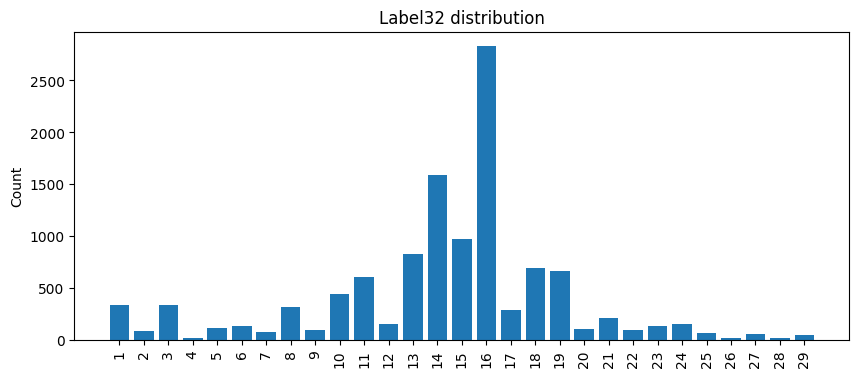

In [74]:
import matplotlib.pyplot as plt

counts = df["label32"].value_counts().sort_index()
plt.figure(figsize=(10,4))
plt.bar(counts.index.astype(str), counts.values)
plt.xticks(rotation=90)
plt.title("Label32 distribution")
plt.ylabel("Count")
plt.show()

inspection 

finding csv 

In [76]:
import os

target_files = [
    "scenario23_img_beam_train.csv",
    "scenario23_img_beam_val.csv",
    "scenario23_img_beam_test.csv",
    "scenario23_pos_beam_train.csv",
    "scenario23_pos_beam_val.csv",
    "scenario23_pos_beam_test.csv",
]

found = []
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f in target_files:
            found.append(os.path.join(root, f))

print("Found files:")
for p in found:
    print(p)

Found files:


In [77]:
print("Hello world")

Hello world


image like author 

In [6]:
import os

author_dir = "/content/Image beam"
os.makedirs(author_dir, exist_ok=True)


print(author_dir)

/content/Image beam


In [31]:
AUTHOR_ROOT = "/content/drive/MyDrive/Image beam"

In [41]:
DATA_ROOT = "/content/dataset/scenario23_dev"   # update if needed
print("Exists:", os.path.exists(DATA_ROOT))

Exists: True


In [42]:
import os

AUTHOR_ROOT = "/content/drive/MyDrive/Image beam"  # adjust path

needed = [
    "build_net.py",
    "data_feed.py",
    "main_beam.py",
    "main_beam_eval.py",
    "scenario23_img_beam_train.csv",
    "scenario23_img_beam_val.csv",
    "scenario23_img_beam_test.csv",
]

for f in needed:
    p = os.path.join(AUTHOR_ROOT, f)
    print(f, "->", os.path.exists(p), p)

build_net.py -> True /content/drive/MyDrive/Image beam/build_net.py
data_feed.py -> True /content/drive/MyDrive/Image beam/data_feed.py
main_beam.py -> True /content/drive/MyDrive/Image beam/main_beam.py
main_beam_eval.py -> True /content/drive/MyDrive/Image beam/main_beam_eval.py
scenario23_img_beam_train.csv -> True /content/drive/MyDrive/Image beam/scenario23_img_beam_train.csv
scenario23_img_beam_val.csv -> True /content/drive/MyDrive/Image beam/scenario23_img_beam_val.csv
scenario23_img_beam_test.csv -> True /content/drive/MyDrive/Image beam/scenario23_img_beam_test.csv


In [43]:
import pandas as pd

train_csv = os.path.join(AUTHOR_ROOT, "scenario23_img_beam_train.csv")
df_img_author = pd.read_csv(train_csv)

print(df_img_author.head())
print(df_img_author.columns.tolist())

   index                                          unit1_rgb  unit1_beam
0   3532  ../scenario23_dev/unit1/camera_data/image_BS1_...          17
1   2224  ../scenario23_dev/unit1/camera_data/image_BS1_...          14
2   9416  ../scenario23_dev/unit1/camera_data/image_BS1_...          17
3   8510  ../scenario23_dev/unit1/camera_data/image_BS1_...          20
4   6877  ../scenario23_dev/unit1/camera_data/image_BS1_...          17
['index', 'unit1_rgb', 'unit1_beam']


In [44]:
sample_paths = df_img_author.iloc[:10, 1].tolist()
print(sample_paths)

for p in sample_paths[:5]:
    print("RAW:", p, "EXISTS:", os.path.exists(str(p)))

['../scenario23_dev/unit1/camera_data/image_BS1_3532_17_08_22.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_2224_17_04_35.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_10033_17_56_07.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_9127_17_53_50.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_7494_17_48_19.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_3825_17_09_10.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_2258_17_04_41.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_2121_17_04_20.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_11899_18_02_04.jpg', '../scenario23_dev/unit1/camera_data/image_BS1_8210_17_50_08.jpg']
RAW: ../scenario23_dev/unit1/camera_data/image_BS1_3532_17_08_22.jpg EXISTS: False
RAW: ../scenario23_dev/unit1/camera_data/image_BS1_2224_17_04_35.jpg EXISTS: False
RAW: ../scenario23_dev/unit1/camera_data/image_BS1_10033_17_56_07.jpg EXISTS: False
RAW: ../scenario23_dev/unit1/camera_data/image_BS1_9127_17_53_50.jpg EXISTS: 

build file name to image path map 

In [45]:
from pathlib import Path

image_map = {}
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            image_map[f] = os.path.join(root, f)

print("Indexed images:", len(image_map))
print(list(image_map.items())[:5])

Indexed images: 11387
[('image_BS1_379_16_59_31.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_379_16_59_31.jpg'), ('image_BS1_3857_17_09_15.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3857_17_09_15.jpg'), ('image_BS1_2719_17_05_56.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_2719_17_05_56.jpg'), ('image_BS1_10364_17_56_56.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10364_17_56_56.jpg'), ('image_BS1_5298_17_14_32.jpg', '/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_5298_17_14_32.jpg')]


In [46]:
def fix_img_csv_paths(csv_path, out_path):
    dfc = pd.read_csv(csv_path).copy()

    # author code takes row.values[1:3], so column index 1 must be image path
    path_col = dfc.columns[1]

    dfc[path_col] = dfc[path_col].apply(lambda x: image_map.get(os.path.basename(str(x).strip()), str(x)))
    dfc.to_csv(out_path, index=False)

    print("Saved:", out_path)
    print(dfc.head())
    return dfc

fixed_train = fix_img_csv_paths(
    os.path.join(AUTHOR_ROOT, "scenario23_img_beam_train.csv"),
    "/content/scenario23_img_beam_train_fixed.csv"
)

fixed_val = fix_img_csv_paths(
    os.path.join(AUTHOR_ROOT, "scenario23_img_beam_val.csv"),
    "/content/scenario23_img_beam_val_fixed.csv"
)

fixed_test = fix_img_csv_paths(
    os.path.join(AUTHOR_ROOT, "scenario23_img_beam_test.csv"),
    "/content/scenario23_img_beam_test_fixed.csv"
)

Saved: /content/scenario23_img_beam_train_fixed.csv
   index                                          unit1_rgb  unit1_beam
0   3532  /content/dataset/scenario23_dev/unit1/camera_d...          17
1   2224  /content/dataset/scenario23_dev/unit1/camera_d...          14
2   9416  /content/dataset/scenario23_dev/unit1/camera_d...          17
3   8510  /content/dataset/scenario23_dev/unit1/camera_d...          20
4   6877  /content/dataset/scenario23_dev/unit1/camera_d...          17
Saved: /content/scenario23_img_beam_val_fixed.csv
   index                                          unit1_rgb  unit1_beam
0   1542  /content/dataset/scenario23_dev/unit1/camera_d...          17
1   6743  /content/dataset/scenario23_dev/unit1/camera_d...          10
2  10999  /content/dataset/scenario23_dev/unit1/camera_d...           2
3   5992  /content/dataset/scenario23_dev/unit1/camera_d...          15
4   7698  /content/dataset/scenario23_dev/unit1/camera_d...           7
Saved: /content/scenario23_img_bea

In [47]:
for p in fixed_train.iloc[:10, 1].tolist():
    print(p, os.path.exists(str(p)))

/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3532_17_08_22.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_2224_17_04_35.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_10033_17_56_07.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_9127_17_53_50.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_7494_17_48_19.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_3825_17_09_10.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_2258_17_04_41.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_2121_17_04_20.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_11899_18_02_04.jpg True
/content/dataset/scenario23_dev/unit1/camera_data/image_BS1_8210_17_50_08.jpg True


In [48]:
from skimage import io
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch

def create_samples(root):
    f = pd.read_csv(root)
    data_samples = []
    for idx, row in f.iterrows():
        img_paths = row.values[1:3]
        data_samples.append(img_paths)
    return data_samples

class DataFeedAuthor(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = root_dir
        self.samples = create_samples(self.root)
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = io.imread(sample[0])
        if self.transform:
            img = self.transform(img)
        label = int(sample[1])
        return img, label

In [49]:
import torchvision.transforms as transf

img_resize = transf.Resize((224, 224))
img_norm = transf.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))

proc_pipe = transf.Compose([
    transf.ToPILImage(),
    img_resize,
    transf.ToTensor(),
    img_norm
])

In [50]:
batch_size = 64
val_batch_size = 64

train_loader_img = DataLoader(
    DataFeedAuthor("/content/scenario23_img_beam_train_fixed.csv", transform=proc_pipe),
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader_img = DataLoader(
    DataFeedAuthor("/content/scenario23_img_beam_val_fixed.csv", transform=proc_pipe),
    batch_size=val_batch_size,
    shuffle=True, num_workers=2
)

test_loader_img = DataLoader(
    DataFeedAuthor("/content/scenario23_img_beam_test_fixed.csv", transform=proc_pipe),
    batch_size=val_batch_size,
    shuffle=False
)

test cell 

In [51]:
imgs, labels = next(iter(train_loader_img))
print(imgs.shape, labels.shape)
print(labels[:10])

torch.Size([64, 3, 224, 224]) torch.Size([64])
tensor([17, 19, 14, 17, 11,  8, 19, 17, 15, 20])


In [52]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_img = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_img.fc = nn.Linear(model_img.fc.in_features, 64)   # author code uses 64
model_img = model_img.to(device)

print(model_img.fc)

Device: cuda
Linear(in_features=2048, out_features=64, bias=True)


In [53]:
import torch

def evaluate_topk(model, loader, device, ks=(1, 2, 3, 5)):
    model.eval()

    total = 0
    correct = {k: 0 for k in ks}

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            max_k = max(ks)
            _, pred = torch.topk(outputs, k=max_k, dim=1)
            pred = pred.t()

            total += labels.size(0)

            for k in ks:
                correct_k = pred[:k].eq(labels.view(1, -1)).sum().item()
                correct[k] += correct_k

    return {f"top{k}": 100.0 * correct[k] / total for k in ks}

In [54]:
import torch.optim as optim
import pandas as pd

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_img.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[4, 8, 12], gamma=0.1)

num_epochs = 20
best_top1 = -1
best_state = None
history = []

for epoch in range(1, num_epochs + 1):
    model_img.train()
    running_loss = 0.0
    total_train = 0

    for imgs, labels in train_loader_img:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_img(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        total_train += bs

    scheduler.step()

    train_loss = running_loss / total_train
    val_metrics = evaluate_topk(model_img, val_loader_img, device, ks=(1, 2, 3, 5))

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **val_metrics
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Top1: {val_metrics['top1']:.2f} | "
        f"Top2: {val_metrics['top2']:.2f} | "
        f"Top3: {val_metrics['top3']:.2f} | "
        f"Top5: {val_metrics['top5']:.2f}"
    )

    if val_metrics["top1"] > best_top1:
        best_top1 = val_metrics["top1"]
        best_state = {k: v.detach().cpu().clone() for k, v in model_img.state_dict().items()}
        torch.save(best_state, "/content/best_resnet50_img.pth")
        print("Saved best model")

Epoch 01 | Train Loss: 0.9424 | Top1: 85.16 | Top2: 97.48 | Top3: 98.95 | Top5: 99.36
Saved best model
Epoch 02 | Train Loss: 0.4483 | Top1: 83.40 | Top2: 97.54 | Top3: 99.12 | Top5: 99.56
Epoch 03 | Train Loss: 0.4182 | Top1: 84.48 | Top2: 97.57 | Top3: 99.12 | Top5: 99.68
Epoch 04 | Train Loss: 0.3935 | Top1: 86.12 | Top2: 97.51 | Top3: 99.33 | Top5: 99.62
Saved best model
Epoch 05 | Train Loss: 0.2800 | Top1: 88.00 | Top2: 98.48 | Top3: 99.36 | Top5: 99.71
Saved best model
Epoch 06 | Train Loss: 0.2458 | Top1: 88.03 | Top2: 98.33 | Top3: 99.30 | Top5: 99.68
Saved best model
Epoch 07 | Train Loss: 0.2122 | Top1: 87.00 | Top2: 98.27 | Top3: 99.27 | Top5: 99.62
Epoch 08 | Train Loss: 0.1810 | Top1: 87.18 | Top2: 98.13 | Top3: 99.27 | Top5: 99.68
Epoch 09 | Train Loss: 0.1318 | Top1: 87.12 | Top2: 98.19 | Top3: 99.39 | Top5: 99.68
Epoch 10 | Train Loss: 0.1123 | Top1: 87.12 | Top2: 98.10 | Top3: 99.33 | Top5: 99.68
Epoch 11 | Train Loss: 0.1048 | Top1: 87.21 | Top2: 97.92 | Top3: 99.33 

In [58]:
hist_img = pd.DataFrame(history)
hist_img

,epoch,train_loss,top1,top2,top3,top5
0,1,0.942356,85.158080,97.482436,98.946136,99.355972
1,2,0.448339,83.401639,97.540984,99.121780,99.560890
2,3,0.418172,84.484778,97.570258,99.121780,99.677986
3,4,0.393497,86.124122,97.511710,99.326698,99.619438
4,5,0.279960,87.997658,98.477752,99.355972,99.707260
5,6,0.245830,88.026932,98.331382,99.297424,99.677986
6,7,0.212182,87.002342,98.272834,99.268150,99.619438
7,8,0.180967,87.177986,98.126464,99.268150,99.677986
8,9,0.131780,87.119438,98.185012,99.385246,99.677986
9,10,0.112266,87.119438,98.097190,99.326698,99.677986


In [59]:
best_state = torch.load("/content/best_resnet50_img.pth", map_location=device)
model_img.load_state_dict(best_state)
model_img = model_img.to(device)

test_metrics = evaluate_topk(model_img, test_loader_img, device, ks=(1, 2, 3, 5))
print("Test metrics:", test_metrics)

Test metrics: {'top1': 87.62071992976296, 'top2': 97.80509218612818, 'top3': 99.3854258121159, 'top5': 99.82440737489026}


In [60]:
results_img = pd.DataFrame([{
    "Modality": "Image (ResNet50)",
    "Top-1": test_metrics["top1"],
    "Top-2": test_metrics["top2"],
    "Top-3": test_metrics["top3"],
    "Top-5": test_metrics["top5"],
}])

results_img

,Modality,Top-1,Top-2,Top-3,Top-5
0,Image (ResNet50),87.62072,97.805092,99.385426,99.824407


mlp cell 

In [62]:
AUTHOR_POS_ROOT = "/content/drive/MyDrive/Pos beam"   # change path if needed

In [63]:
pos_train_csv = os.path.join(AUTHOR_POS_ROOT, "scenario23_pos_beam_train.csv")
pos_val_csv   = os.path.join(AUTHOR_POS_ROOT, "scenario23_pos_beam_val.csv")
pos_test_csv  = os.path.join(AUTHOR_POS_ROOT, "scenario23_pos_beam_test.csv")

df_pos_author = pd.read_csv(pos_train_csv)
print(df_pos_author.head())
print(df_pos_author.columns.tolist())

   index                                  unit2_pos  unit1_beam
0   3532    [0.8092883966431671, 0.521083920903955]          17
1   2224  [0.4816276084988933, 0.29434536152734486]          14
2   9416    [0.220278556834608, 0.4136596156292844]          17
3   8510  [0.21412273613497904, 0.4547214157104936]          20
4   6877  [0.14500641727379412, 0.4097884695072434]          17
['index', 'unit2_pos', 'unit1_beam']


In [64]:
import ast
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader

def create_pos_samples(root):
    f = pd.read_csv(root)
    data_samples = []
    for _, row in f.iterrows():
        data = list(row.values[1:])
        data_samples.append(data)
    return data_samples

class DataFeedPosAuthor(Dataset):
    def __init__(self, root_dir):
        self.root = root_dir
        self.samples = create_pos_samples(self.root)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        pos_val = sample[:1]
        pos_val = ast.literal_eval(pos_val[0])
        pos_val = np.asarray(pos_val, dtype=np.float32)

        pos_centers = sample[1:2]
        pos_centers = np.asarray(pos_centers, dtype=np.int64)

        return pos_val, pos_centers

In [65]:
batch_size = 128
val_batch_size = 64

train_loader_pos_author = DataLoader(
    DataFeedPosAuthor(pos_train_csv),
    batch_size=batch_size,
    shuffle=False
)

val_loader_pos_author = DataLoader(
    DataFeedPosAuthor(pos_val_csv),
    batch_size=val_batch_size,
    shuffle=False
)

test_loader_pos_author = DataLoader(
    DataFeedPosAuthor(pos_test_csv),
    batch_size=val_batch_size,
    shuffle=False
)

test the one batch

In [66]:
pos_batch, label_batch = next(iter(train_loader_pos_author))
print(pos_batch.shape, label_batch.shape)
print(pos_batch[:3])
print(label_batch[:10])

torch.Size([128, 2]) torch.Size([128, 1])
tensor([[0.8093, 0.5211],
        [0.4816, 0.2943],
        [0.2203, 0.4137]])
tensor([[17],
        [14],
        [17],
        [20],
        [17],
        [17],
        [12],
        [ 9],
        [17],
        [12]])


In [67]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = 2
node = 512
output_size = 65

class NN_beam_pred(nn.Module):
    def __init__(self, num_features, num_output):
        super(NN_beam_pred, self).__init__()
        self.layer_1 = nn.Linear(num_features, node)
        self.layer_2 = nn.Linear(node, node)
        self.layer_3 = nn.Linear(node, node)
        self.layer_out = nn.Linear(node, num_output)
        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.relu(self.layer_1(inputs))
        x = self.relu(self.layer_2(x))
        x = self.relu(self.layer_3(x))
        x = self.layer_out(x)
        return x

model_pos_author = NN_beam_pred(input_size, output_size).to(device)
print(model_pos_author)

NN_beam_pred(
  (layer_1): Linear(in_features=2, out_features=512, bias=True)
  (layer_2): Linear(in_features=512, out_features=512, bias=True)
  (layer_3): Linear(in_features=512, out_features=512, bias=True)
  (layer_out): Linear(in_features=512, out_features=65, bias=True)
  (relu): ReLU()
)


In [68]:
def evaluate_topk_pos(model, loader, device, ks=(1, 2, 3)):
    model.eval()

    total = 0
    correct = {k: 0 for k in ks}

    with torch.no_grad():
        for pos_data, beam_val in loader:
            x = pos_data.float().to(device)
            labels = beam_val[:, 0].long().to(device)

            out = model(x)

            max_k = max(ks)
            _, pred = torch.topk(out, k=max_k, dim=1)
            pred = pred.t()

            total += labels.size(0)

            for k in ks:
                correct_k = pred[:k].eq(labels.view(1, -1)).sum().item()
                correct[k] += correct_k

    return {f"top{k}": 100.0 * correct[k] / total for k in ks}

In [70]:
import torch.optim as optim


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pos_author.parameters(), lr=0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 25, 40], gamma=0.1)

num_epochs = 100
best_top1 = -1
best_state = None
history_pos = []

for epoch in range(1, num_epochs + 1):
    model_pos_author.train()
    running_loss = 0.0
    total_train = 0

    for pos_data, beam_val in train_loader_pos_author:
        x = pos_data.float().to(device)
        labels = beam_val[:, 0].long().to(device)

        optimizer.zero_grad()
        out = model_pos_author(x)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        total_train += bs

    scheduler.step()

    train_loss = running_loss / total_train
    val_metrics = evaluate_topk_pos(model_pos_author, val_loader_pos_author, device, ks=(1, 2, 3))

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **val_metrics
    }
    history_pos.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Top1: {val_metrics['top1']:.2f} | "
        f"Top2: {val_metrics['top2']:.2f} | "
        f"Top3: {val_metrics['top3']:.2f}"
    )

    if val_metrics["top1"] > best_top1:
        best_top1 = val_metrics["top1"]
        best_state = {k: v.detach().cpu().clone() for k, v in model_pos_author.state_dict().items()}
        torch.save(best_state, "/content/best_pos_author.pth")
        print("Saved best position model")

Epoch 01 | Train Loss: 1.2265 | Top1: 59.43 | Top2: 80.47 | Top3: 89.58
Saved best position model
Epoch 02 | Train Loss: 1.1474 | Top1: 59.13 | Top2: 80.94 | Top3: 90.22
Epoch 03 | Train Loss: 1.1389 | Top1: 58.93 | Top2: 80.68 | Top3: 90.25
Epoch 04 | Train Loss: 1.1408 | Top1: 58.69 | Top2: 80.97 | Top3: 90.72
Epoch 05 | Train Loss: 1.1356 | Top1: 59.60 | Top2: 81.29 | Top3: 91.10
Saved best position model
Epoch 06 | Train Loss: 1.1336 | Top1: 59.98 | Top2: 81.82 | Top3: 91.04
Saved best position model
Epoch 07 | Train Loss: 1.1215 | Top1: 58.64 | Top2: 81.18 | Top3: 91.10
Epoch 08 | Train Loss: 1.1320 | Top1: 59.54 | Top2: 80.94 | Top3: 90.78
Epoch 09 | Train Loss: 1.1203 | Top1: 60.10 | Top2: 81.56 | Top3: 91.10
Saved best position model
Epoch 10 | Train Loss: 1.1213 | Top1: 59.02 | Top2: 80.85 | Top3: 91.01
Epoch 11 | Train Loss: 1.1170 | Top1: 60.13 | Top2: 81.35 | Top3: 91.16
Saved best position model
Epoch 12 | Train Loss: 1.1127 | Top1: 59.13 | Top2: 80.83 | Top3: 91.25
Epoch 

In [71]:
best_state = torch.load("/content/best_pos_author.pth", map_location=device)
model_pos_author.load_state_dict(best_state)
model_pos_author = model_pos_author.to(device)

test_metrics_pos = evaluate_topk_pos(model_pos_author, test_loader_pos_author, device, ks=(1, 2, 3))
print("Position Test metrics:", test_metrics_pos)

Position Test metrics: {'top1': 58.91132572431958, 'top2': 83.40649692712906, 'top3': 92.71290605794556}


In [72]:
results_pos = pd.DataFrame([{
    "Modality": "Position (Author MLP)",
    "Top-1": test_metrics_pos["top1"],
    "Top-2": test_metrics_pos["top2"],
    "Top-3": test_metrics_pos["top3"],
}])

results_pos

,Modality,Top-1,Top-2,Top-3
0,Position (Author MLP),58.911326,83.406497,92.712906
